In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot") # Set the default plotting style to 'ggplot' for better-looking visualizations


pd.set_option("display.max_columns", None)  # Display all columns of a DataFrame when printing the output


In [2]:
# Load both datasets 
fear_df = pd.read_csv(r"C:\Users\deepa\OneDrive\Documents\Days\Assignment\fear_greed_index.csv")

trader_df = pd.read_csv(r"C:\Users\deepa\OneDrive\Documents\Days\Assignment\historical_data.csv")


In [3]:
#Dataset Information checking - Fear Dataset
fear_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
fear_df.tail()

,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


In [6]:
fear_df.shape

(2644, 4)

In [7]:
fear_df.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [8]:
fear_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [9]:
#Dataset Information checking - Trader Dataset 
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
trader_df.tail()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [11]:
trader_df.shape

(211224, 16)

In [12]:
trader_df.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [13]:
trader_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [15]:
pd.DataFrame({
    "Column": trader_df.columns,
    "Data Type": trader_df.dtypes.values
})

,Column,Data Type
0,Account,str
1,Coin,str
2,Execution Price,float64
3,Size Tokens,float64
4,Size USD,float64
5,Side,str
6,Timestamp IST,str
7,Start Position,float64
8,Direction,str
9,Closed PnL,float64


In [17]:
# Data cleaning 
# a - checking missing values in both data sets 

In [18]:
fear_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [19]:
trader_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [20]:
# b - checking Duplicate value 



In [21]:
fear_df.duplicated().sum()

np.int64(0)

In [22]:
trader_df.duplicated().sum()

np.int64(0)

In [23]:
 # Data Cleaning Summary :-
#  No null (missing) values found
# No duplicate rows found


In [24]:
# Convert Date Columns

In [26]:
# check  first data frame 

pd.DataFrame({
    "Column": fear_df.columns,
    "Data Type": fear_df.dtypes.values # 
})


,Column,Data Type
0,timestamp,int64
1,value,int64
2,classification,str
3,date,str


In [27]:
# check second data frame 
pd.DataFrame({
    "Column": trader_df.columns,
    "Data Type": trader_df.dtypes.values # 
})


,Column,Data Type
0,Account,str
1,Coin,str
2,Execution Price,float64
3,Size Tokens,float64
4,Size USD,float64
5,Side,str
6,Timestamp IST,str
7,Start Position,float64
8,Direction,str
9,Closed PnL,float64


In [29]:
fear_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [30]:
# Convert the 'date' column to datetime format
fear_df["date"] = pd.to_datetime(fear_df["date"])

In [31]:
fear_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   str           
 3   date            2644 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 82.8 KB


In [32]:
trader_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [35]:
trader_df[["Timestamp", "Timestamp IST"]].head()

,Timestamp,Timestamp IST
0,1.730000e+12,02-12-2024 22:50
1,1.730000e+12,02-12-2024 22:50
2,1.730000e+12,02-12-2024 22:50
3,1.730000e+12,02-12-2024 22:50
4,1.730000e+12,02-12-2024 22:50


In [36]:
# Convert Timestamp IST to datetime
trader_df["Timestamp IST"] = pd.to_datetime(
    trader_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [37]:
trader_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [38]:
# Create a Date column from Timestamp IST
trader_df["Date"] = trader_df["Timestamp IST"].dt.normalize()

In [39]:
trader_df[["Timestamp IST", "Date"]].head() # checking 

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [40]:
# Rename the column name in first dataframe 
fear_df.rename(columns={"date": "Date"}, inplace=True) # Rename 'date' column to 'Date'


In [41]:
fear_df.columns

Index(['timestamp', 'value', 'classification', 'Date'], dtype='str')

In [43]:
trader_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date'],
      dtype='str')

In [44]:
# Merge Both Datasets 

In [45]:
# Merge trader data with Fear & Greed data using the Date column
merged_df = pd.merge(
    trader_df,
    fear_df,
    on="Date",
    how="left"
)

In [46]:
# check the number of rows and columns
merged_df.shape

(211224, 20)

In [47]:
merged_df.head() # the first five rows of the merged dataset

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [49]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [50]:
merged_df[["Date", "classification", "value"]].head(10) # Display sentiment information after merging

,Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0
5,2024-12-02,Extreme Greed,80.0
6,2024-12-02,Extreme Greed,80.0
7,2024-12-02,Extreme Greed,80.0
8,2024-12-02,Extreme Greed,80.0
9,2024-12-02,Extreme Greed,80.0


In [51]:
merged_df.isnull().sum() # Check missing values in the merged dataset

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
timestamp           6
value               6
classification      6
dtype: int64

In [52]:
# Check the rows where market sentiment is missing
merged_df[merged_df["classification"].isnull()][["Date"]]

,Date
727,2024-10-26
728,2024-10-26
729,2024-10-26
730,2024-10-26
731,2024-10-26
732,2024-10-26


In [53]:
merged_df.dropna(subset=["classification"], inplace=True) # Remove rows where market sentiment is missing

In [54]:
# Now again check missing values 
merged_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
timestamp           0
value               0
classification      0
dtype: int64

In [55]:
# Analysis 

In [57]:
# Create a Win column (1 = Profit, 0 = Loss)
merged_df["Win"] = (merged_df["Closed PnL"] > 0).astype(int)

In [69]:
merged_df[["Closed PnL", "Win"]].head(50)

,Closed PnL,Win
0,0.000000,0
1,0.000000,0
2,0.000000,0
3,0.000000,0
4,0.000000,0
5,0.000000,0
6,0.000000,0
7,0.000000,0
8,0.000000,0
9,0.000000,0


In [61]:

merged_df["Closed PnL"].describe()

count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: Closed PnL, dtype: float64

In [62]:
# Count of how many trades have positive PnL
(merged_df["Closed PnL"] > 0).sum()

np.int64(86863)

In [63]:
# Count of how many trades have negative PnL
(merged_df["Closed PnL"] < 0).sum()

np.int64(17539)

In [64]:
# Count of how many trades have zero PnL
(merged_df["Closed PnL"] == 0).sum()

np.int64(106816)

In [70]:
# Calculate of total Profit And Loss for each day

In [73]:
daily_pnl = (
    merged_df.groupby("Date")["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [74]:
# Calculate of daily win rate

In [77]:
daily_win_rate = (
    merged_df.groupby("Date")["Win"]
    .mean()
    .reset_index()
)

daily_win_rate["Win"] = daily_win_rate["Win"] * 100

daily_win_rate.head() 

,Date,Win
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,36.363636
3,2023-12-15,0.000000
4,2023-12-16,0.000000


In [78]:
# Calculate of average trade size per day

In [79]:
avg_trade_size = (
    merged_df.groupby("Date")["Size USD"]
    .mean()
    .reset_index()
)

avg_trade_size.head()

,Date,Size USD
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667


In [80]:
# Calculate of total number of trades per day

In [81]:
trades_per_day = (
    merged_df.groupby("Date")
    .size()
    .reset_index(name="Total Trades")
)

trades_per_day.head()

,Date,Total Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [83]:
# Calculate Long vs Short Ratio

In [85]:
merged_df["Side"].unique() # All unique values in the Side column


<StringArray>
['BUY', 'SELL']
Length: 2, dtype: str

In [111]:
merged_df["Side"].value_counts() # Count the number of trades for each Side

Side
SELL    108528
BUY     102690
Name: count, dtype: int64

In [87]:
# Calculate Long {BUY} vs Short {SELL} ratio
long_short_ratio = merged_df["Side"].value_counts(normalize=True) * 100

long_short_ratio

Side
SELL    51.381984
BUY     48.618016
Name: proportion, dtype: float64

In [112]:
# Convert Long vs Short percentage into a DataFrame
long_short_ratio = merged_df["Side"].value_counts(normalize=True) * 100

long_short_ratio = long_short_ratio.reset_index()

long_short_ratio.columns = ["Side", "Percentage"]

long_short_ratio

,Side,Percentage
0,SELL,51.381984
1,BUY,48.618016


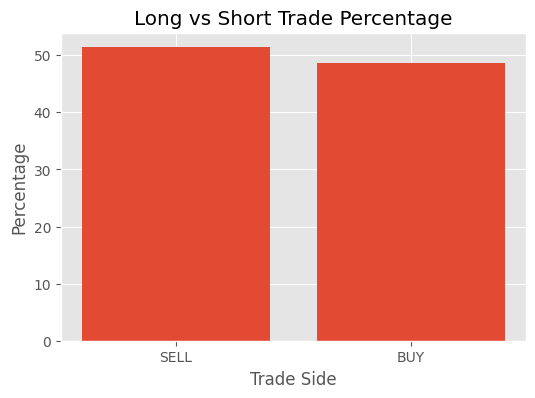

In [113]:
# Plot Long vs Short percentage
plt.figure(figsize=(6,4))

plt.bar(long_short_ratio["Side"], long_short_ratio["Percentage"])

plt.title("Long vs Short Trade Percentage")
plt.xlabel("Trade Side")
plt.ylabel("Percentage")

plt.show()

In [93]:
# Create Fear vs Greed Summary Table 

In [114]:
# Compare trader performance between Fear and Greed days

In [95]:
fear_greed_summary = merged_df.groupby("classification").agg(
    Average_PnL=("Closed PnL", "mean"),
    Total_PnL=("Closed PnL", "sum"),
    Win_Rate=("Win", "mean"),
    Average_Trade_Size=("Size USD", "mean"),
    Total_Trades=("Account", "count")
).reset_index()

# Convert Win Rate to percentage
fear_greed_summary["Win_Rate"] = fear_greed_summary["Win_Rate"] * 100

fear_greed_summary

,classification,Average_PnL,Total_PnL,Win_Rate,Average_Trade_Size,Total_Trades
0,Extreme Fear,34.537862,7.391102e+05,37.060748,5349.731843,21400
1,Extreme Greed,67.892861,2.715171e+06,46.494299,3112.251565,39992
2,Fear,54.290400,3.357155e+06,42.076750,7816.109931,61837
3,Greed,42.743559,2.150129e+06,38.482794,5736.884375,50303
4,Neutral,34.307718,1.292921e+06,39.699093,4782.732661,37686


In [96]:
# Visualize Average PnL


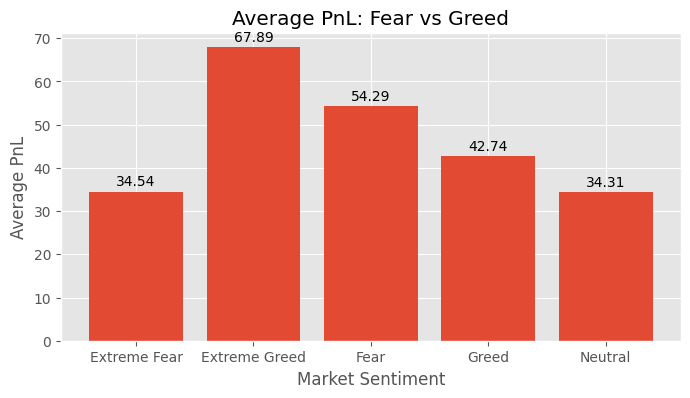

In [99]:
# Plot Average PnL for Fear vs Greed days

plt.figure(figsize=(8,4))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Average_PnL"]
)

plt.bar_label(bars, fmt="%.2f", padding=2)

plt.title("Average PnL: Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

In [100]:
# Visualize Win Rate

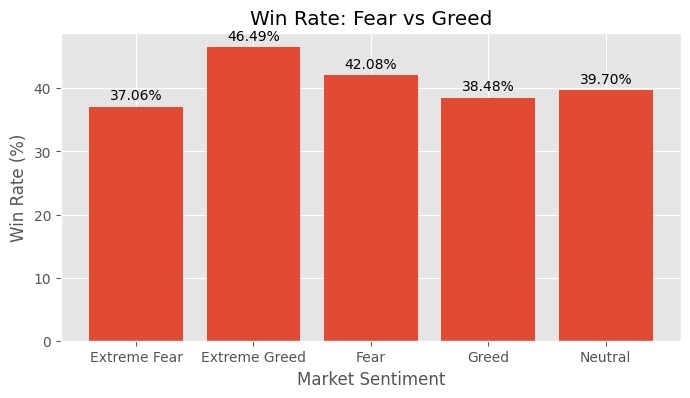

In [101]:
# Plot Win Rate for Fear vs Greed days

plt.figure(figsize=(8,4))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Win_Rate"]
)

plt.bar_label(bars, fmt="%.2f%%", padding=3)

plt.title("Win Rate: Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

In [102]:
# Visualize Average Trade Size

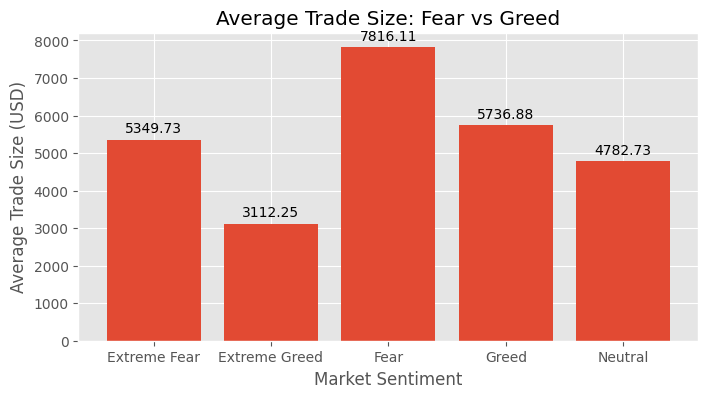

In [104]:
# Plot Average Trade Size for Fear vs Greed days

plt.figure(figsize=(8,4))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Average_Trade_Size"]
)

plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Average Trade Size: Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

In [105]:
fear_greed_summary

,classification,Average_PnL,Total_PnL,Win_Rate,Average_Trade_Size,Total_Trades
0,Extreme Fear,34.537862,7.391102e+05,37.060748,5349.731843,21400
1,Extreme Greed,67.892861,2.715171e+06,46.494299,3112.251565,39992
2,Fear,54.290400,3.357155e+06,42.076750,7816.109931,61837
3,Greed,42.743559,2.150129e+06,38.482794,5736.884375,50303
4,Neutral,34.307718,1.292921e+06,39.699093,4782.732661,37686


In [106]:
# Average Trade Size by Market Sentiment

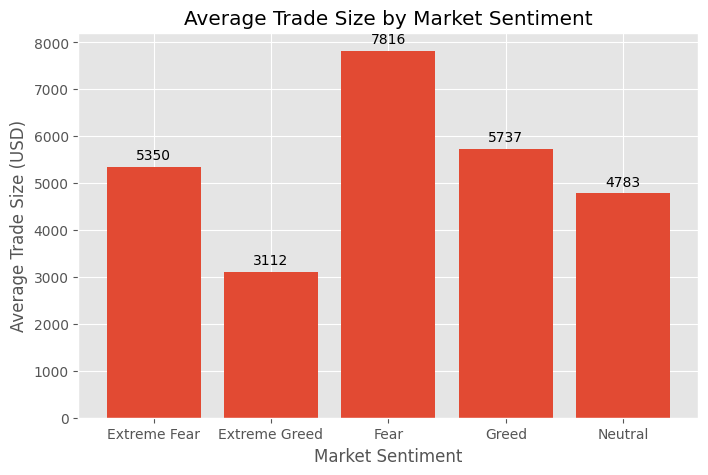

In [107]:
# Visualize the Average Trade Size by Market Sentiment
plt.figure(figsize=(8,5))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Average_Trade_Size"]
)

plt.bar_label(bars, fmt="%.0f", padding=3)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

In [108]:
# Total Trades by Market Sentiment

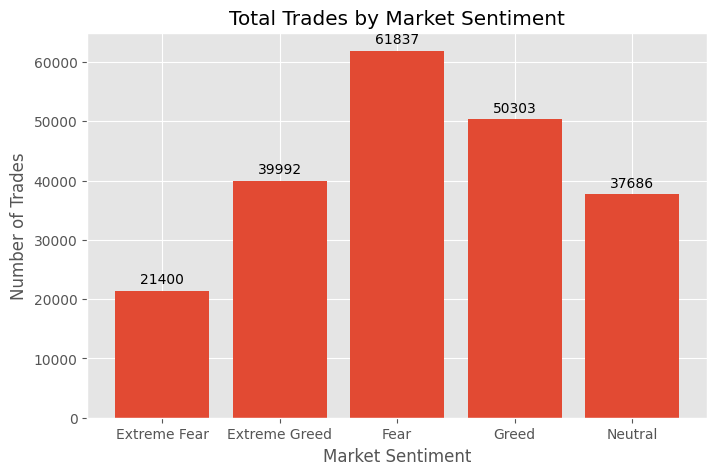

In [115]:
#visualize the Total Number of Trades by Market Sentiment
plt.figure(figsize=(8,5))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Total_Trades"]
)

plt.bar_label(bars, padding=3)

plt.title("Total Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [118]:
# Segment Traders

#Frequent vs Infrequent Traders

In [119]:
# Count the number of trades made by each trader
trader_activity = merged_df["Account"].value_counts()

trader_activity.head()

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
Name: count, dtype: int64

In [120]:
# Convert the result into a DataFrame
trader_activity = trader_activity.reset_index()

trader_activity.columns = ["Account", "Total_Trades"]

trader_activity.head()

,Account,Total_Trades
0,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184
1,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192
2,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15605
3,0x8477e447846c758f5a675856001ea72298fd9cb5,14998
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733


In [121]:
# the average number of trades
average_trades = trader_activity["Total_Trades"].mean()

print(average_trades)

6600.5625


In [122]:
# Classify traders based on average number of trades
trader_activity["Segment"] = ""

for i in trader_activity.index:
    if trader_activity.loc[i, "Total_Trades"] >= average_trades:
        trader_activity.loc[i, "Segment"] = "Frequent Trader"
    else:
        trader_activity.loc[i, "Segment"] = "Infrequent Trader"

trader_activity.head()

,Account,Total_Trades,Segment
0,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,Frequent Trader
1,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,Frequent Trader
2,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15605,Frequent Trader
3,0x8477e447846c758f5a675856001ea72298fd9cb5,14998,Frequent Trader
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,Frequent Trader


In [123]:
# Compare the Segments
segment_summary = (
    trader_activity.groupby("Segment")["Total_Trades"]
    .agg(["count", "mean", "max"])
    .reset_index()
)

segment_summary

,Segment,count,mean,max
0,Frequent Trader,11,15048.636364,40184
1,Infrequent Trader,21,2175.380952,4838


In [124]:
#Insight 1

### During Extreme Greed, traders recorded the highest average profit (67.89 USD) and the highest win rate (46.49)
### This shows that trading performance was stronger when market sentiment was very positive

In [125]:
# Insight 2 
### The Fear category had the highest number of trades (61,837) and the largest average trade size (7,816.11 USD) 
### This indicates that traders were more active and placed larger trades during fear periods

In [126]:
# Insight 3

### Although traders placed larger trades during Fear, the average profit (54.29 USD) was still lower than during Extreme Greed (67.89 USD)
### This suggests that increasing trade size did not necessarily lead to better returns

In [127]:
# Insight 4

### The lowest win rate was observed during Extreme Fear (37.06%)
### This means traders found it more difficult to make profitable trades when the market was under strong negative sentiment

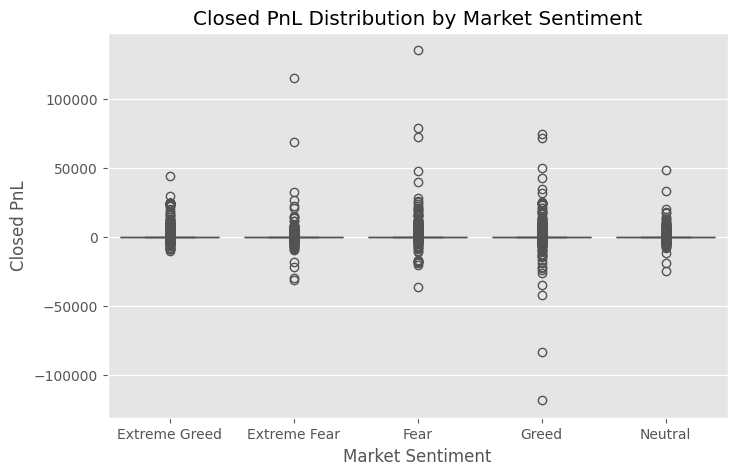

In [152]:
# Box Plot of Closed PnL by Market Sentiment

plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

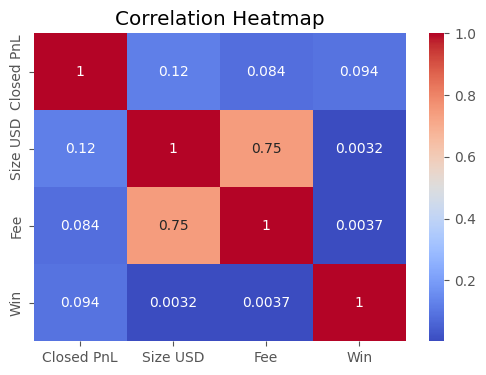

In [133]:
# Correlation Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    merged_df[["Closed PnL","Size USD","Fee","Win"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [135]:
merged_df.to_csv("final_merged_dataset.csv", index=False)

In [131]:
# Actionable Recommendations

## Recommendation 1

### The analysis shows that traders achieved the highest average PnL (67.89 USD) and the highest win rate (46.49%) during Extreme Greed
### Traders can consider market sentiment as an additional confirmation before entering a trade. However, trading decisions should also include technical and risk analysis instead of relying only on sentiment

## Recommendation 2

### During Fear periods, traders executed the highest number of trades (61,837) and had the largest average trade size (7,816.11 USD)
### Instead of increasing position size during uncertain market conditions, traders should maintain disciplined position sizing and apply proper risk management

## Recommendation 3

### The results show that trading performance changes across different market sentiment categories
### Traders should monitor sentiment regularly and adjust their trading strategy based on changing market conditions rather than using the same approach in every market

In [130]:
# Conclusion
## This project analyzed the relationship between Bitcoin market sentiment and trader performance using the Fear & Greed Index and Hyperliquid trading data
## The analysis showed that trader performance varied across different market sentiment categories
## Extreme Greed had the highest Average PnL and Win Rate, while Fear periods recorded the highest trading activity and average trade size

###Overall-  the findings suggest that market sentiment can be a useful factor in understanding trader behavior and supporting better trading decisions when combined with proper risk management

In [146]:
# Extra work 

# For saving all charts in our  folders 

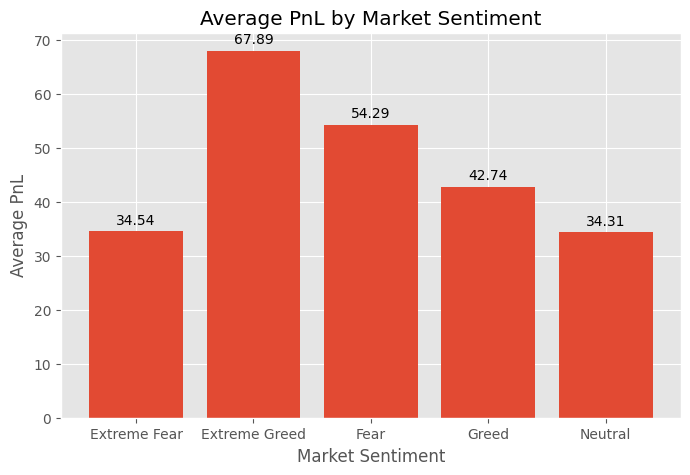

In [145]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Average_PnL"]
)

plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

# Save the chart BEFORE showing it
plt.savefig(
    r"C:\Users\deepa\OneDrive\Documents\Days\Assignment\Charts\average_pnl.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

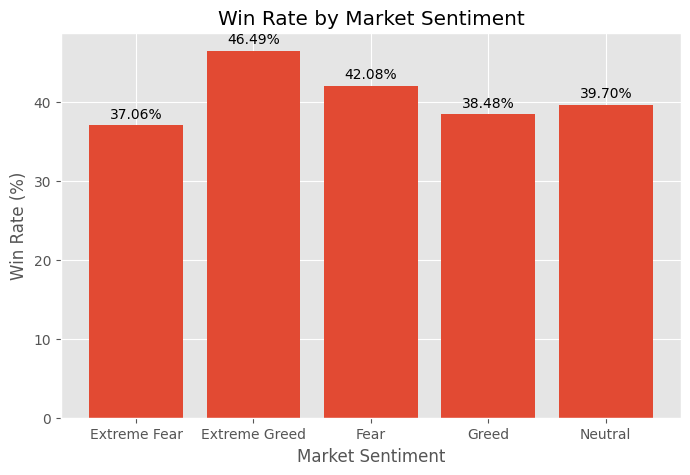

In [147]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Win_Rate"]
)

plt.bar_label(bars, fmt="%.2f%%", padding=3)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.savefig(
    r"C:\Users\deepa\OneDrive\Documents\Days\Assignment\Charts\win_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

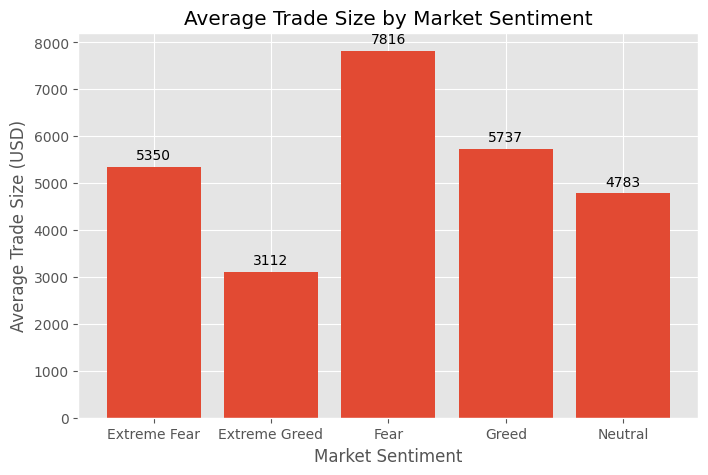

In [148]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Average_Trade_Size"]
)

plt.bar_label(bars, fmt="%.0f", padding=3)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.savefig(
    r"C:\Users\deepa\OneDrive\Documents\Days\Assignment\Charts\average_trade_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

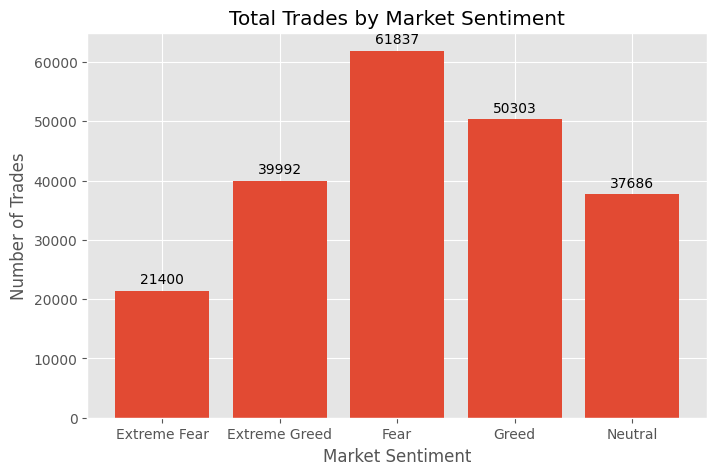

In [149]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    fear_greed_summary["classification"],
    fear_greed_summary["Total_Trades"]
)

plt.bar_label(bars, padding=3)

plt.title("Total Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.savefig(
    r"C:\Users\deepa\OneDrive\Documents\Days\Assignment\Charts\total_trades.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

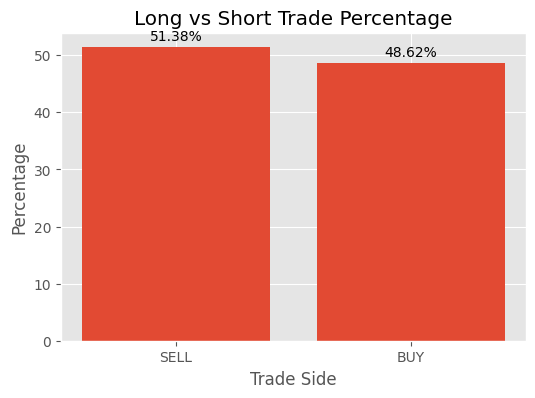

In [150]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    long_short_ratio["Side"],
    long_short_ratio["Percentage"]
)

plt.bar_label(bars, fmt="%.2f%%", padding=3)

plt.title("Long vs Short Trade Percentage")
plt.xlabel("Trade Side")
plt.ylabel("Percentage")

plt.savefig(
    r"C:\Users\deepa\OneDrive\Documents\Days\Assignment\Charts\long_short_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

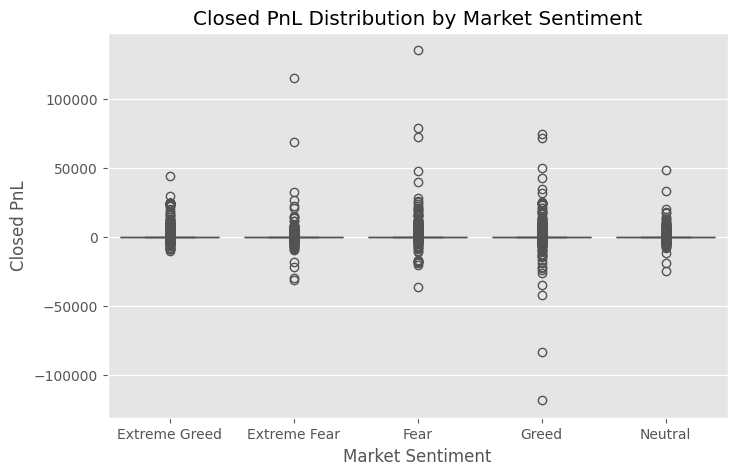

In [151]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.savefig(
    r"C:\Users\deepa\OneDrive\Documents\Days\Assignment\Charts\box_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()